In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Plot PMF

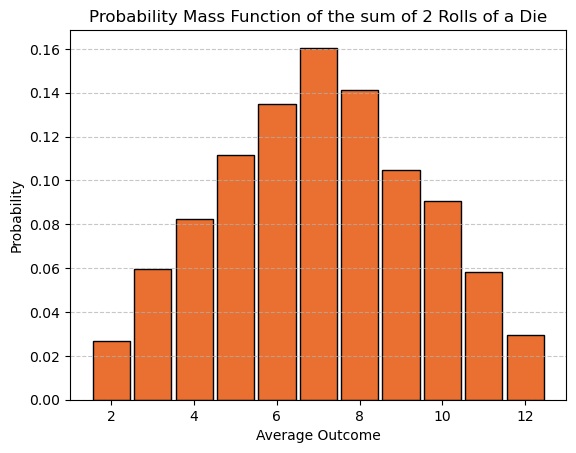

In [2]:
values = []
num_simulations = 10000
for s in range(num_simulations):
    rolls = np.random.randint(1, 7, size=(2, 1))
    values.append(sum(rolls)[0])

counts = Counter(values)
total = sum(counts.values())
pmf = {k: v / total for k, v in counts.items()}


x = sorted(pmf.keys())
y = [pmf[val] for val in x]

plt.bar(x, y, color='#e97031ff', edgecolor='black', width=0.9)
plt.title('Probability Mass Function of the sum of 2 Rolls of a Die')
plt.xlabel('Average Outcome')
plt.ylabel('Probability')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Plot PDF

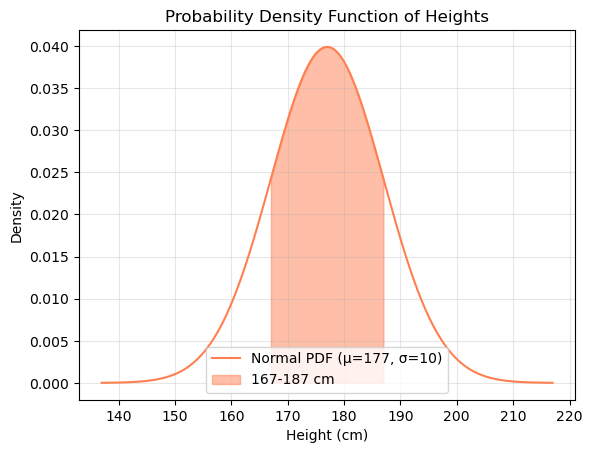

In [3]:
mu = 177 # My height
sigma = 10

heights = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000) 

pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((heights - mu) / sigma) ** 2)

plt.plot(heights, pdf, label=f'Normal PDF (μ={mu}, σ={sigma})', color='coral')
plt.title('Probability Density Function of Heights')
plt.xlabel('Height (cm)')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.legend()

within_range = (heights >= 167) & (heights <= 187)
plt.fill_between(heights[within_range], pdf[within_range], color='coral', alpha=0.5, label='167-187 cm')

# Show the plot
plt.legend()
plt.show()

# Plot third moment of a distribution

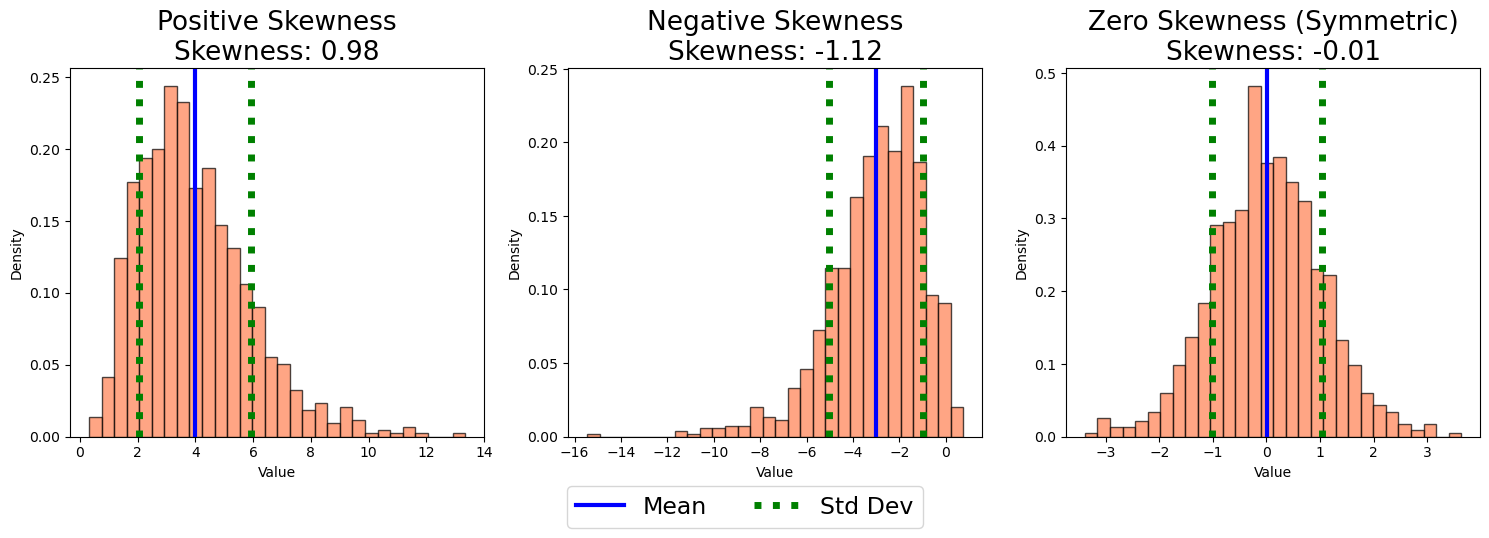

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(51)

size = 1000
positive_skew = np.random.gamma(shape=4, scale=1.0, size=size)
negative_skew = 1 - np.random.gamma(shape=4, scale=1.0, size=size)
symmetric = np.random.normal(loc=0, scale=1, size=size)

pos_skew_moment = stats.skew(positive_skew)
neg_skew_moment = stats.skew(negative_skew)
sym_skew_moment = stats.skew(symmetric)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def plot_distribution(ax, data, title, skewness):
    mean = np.mean(data)
    std = np.std(data)
    ax.hist(data, bins=30, alpha=0.7, color='coral', edgecolor='black', density=True)
    ax.axvline(mean, color='blue', linewidth=3, label='Mean')
    ax.axvline(mean + std, color='green', linestyle='dotted', linewidth=5, label='Std Dev')
    ax.axvline(mean - std, color='green', linestyle='dotted', linewidth=5)
    ax.set_title(f"{title}\nSkewness: {skewness:.2f}", fontsize=19)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")

plot_distribution(axes[0], positive_skew, "Positive Skewness", pos_skew_moment)
plot_distribution(axes[1], negative_skew, "Negative Skewness", neg_skew_moment)
plot_distribution(axes[2], symmetric, "Zero Skewness (Symmetric)", sym_skew_moment)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=17, bbox_to_anchor=(0.5, -0.09))

plt.tight_layout()
plt.show()


# Plot Kurtois moment

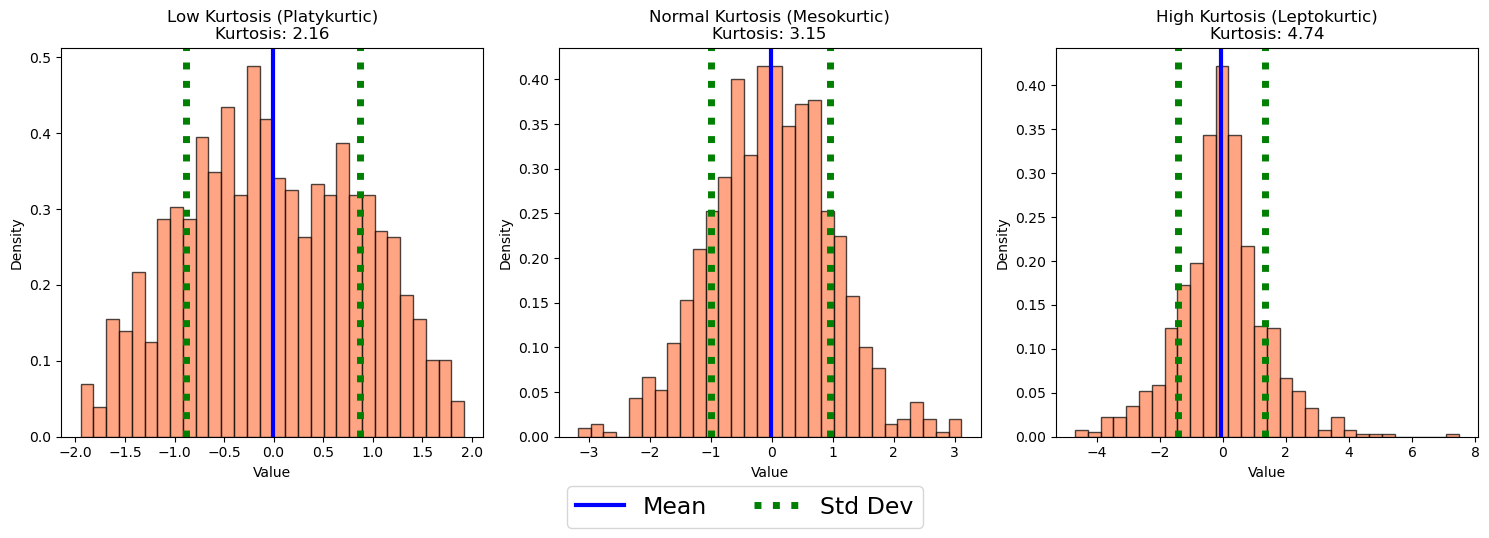

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)

size = 1000
high_kurtosis = np.random.laplace(loc=0, scale=1.0, size=size)
low_kurtosis = np.random.beta(a=2, b=2, size=size) * 4 - 2
normal_kurtosis = np.random.normal(loc=0, scale=1, size=size)

high_kurt_moment = stats.kurtosis(high_kurtosis, fisher=False)
low_kurt_moment = stats.kurtosis(low_kurtosis, fisher=False)
normal_kurt_moment = stats.kurtosis(normal_kurtosis, fisher=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def plot_distribution(ax, data, title, kurtosis):
    mean = np.mean(data)
    std = np.std(data)
    ax.axvline(mean, color='blue', linewidth=3, label='Mean')
    ax.axvline(mean + std, color='green', linestyle='dotted', linewidth=5, label='Std Dev')
    ax.axvline(mean - std, color='green', linestyle='dotted', linewidth=5)

    ax.hist(data, bins=30, alpha=0.7, color='coral', edgecolor='black', density=True)
    ax.set_title(f"{title}\nKurtosis: {kurtosis:.2f}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")

plot_distribution(axes[2], high_kurtosis, "High Kurtosis (Leptokurtic)", high_kurt_moment)
plot_distribution(axes[0], low_kurtosis, "Low Kurtosis (Platykurtic)", low_kurt_moment)
plot_distribution(axes[1], normal_kurtosis, "Normal Kurtosis (Mesokurtic)", normal_kurt_moment)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=17, bbox_to_anchor=(0.5, -0.09))

plt.tight_layout()
plt.show()

# Plot common distributions

In [6]:
from scipy.stats import binom, poisson, geom, nbinom, norm, uniform, expon, gamma, beta, t, lognorm, chi2
import seaborn as sns

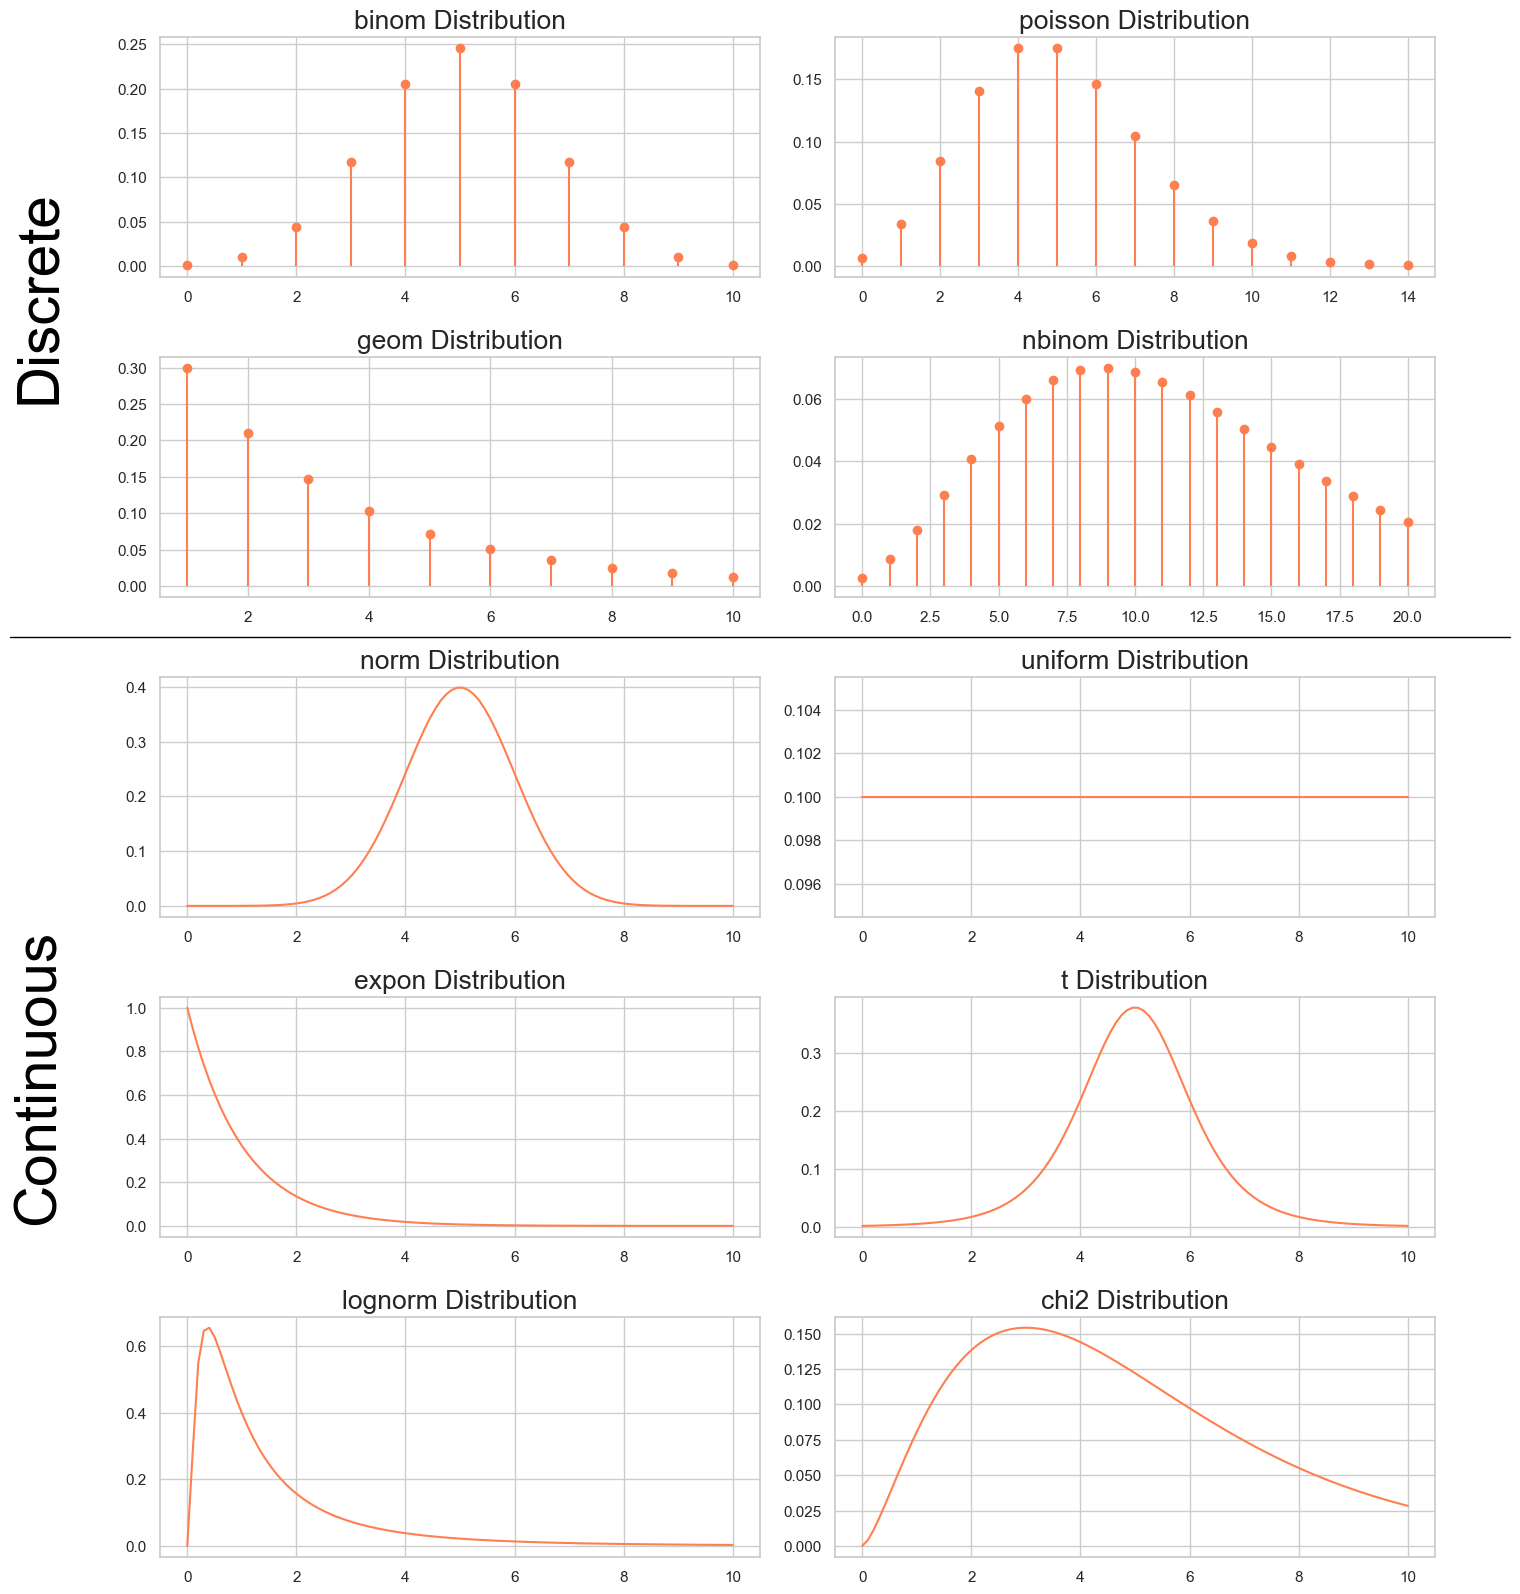

In [7]:
sns.set(style="whitegrid")

fig = plt.figure(figsize=(15, 20))

# Distributions and parameters
distributions = [
    (binom, {'name': 'binom', 'n': 10, 'p': 0.5}),
    (poisson, {'name': 'poisson', 'lambda_poisson': 5}),
    (geom, {'name': 'geom', 'p_geom': 0.3}),
    (nbinom, {'name': 'nbinom', 'r': 5, 'p': 0.3}),
    (norm, {'name': 'norm', 'mu': 5, 'sigma': 1}),
    (uniform, {'name': 'uniform', 'a': 0, 'b': 10}),
    (expon, {'name': 'expon', 'lambda_exp': 1}),
    (t, {'name': 't', 'df': 5, 'loc': 5, 'scale': 1}),
    (lognorm, {'name': 'lognorm', 'mu': 0, 'sigma': 1}),
    (chi2, {'name': 'chi2', 'df_chi2': 5}),
]

# Distribution functions mapping
plot_functions = {
    binom: lambda ax, dist, params: ax.stem(np.arange(0, params['n'] + 1), dist.pmf(np.arange(0, params['n'] + 1), params['n'], params['p']),basefmt=" ", linefmt='coral'),
    poisson: lambda ax, dist, params: ax.stem(np.arange(0, 15), dist.pmf(np.arange(0, 15), params['lambda_poisson']),basefmt=" ", linefmt='coral'),
    geom: lambda ax, dist, params: ax.stem(np.arange(1, 11), dist.pmf(np.arange(1, 11), params['p_geom']),basefmt=" ", linefmt='coral'),
    nbinom: lambda ax, dist, params: ax.stem(np.arange(0, 21), dist.pmf(np.arange(0, 21), params['r'], params['p']),basefmt=" ", linefmt='coral'),
    norm: lambda ax, dist, params: ax.plot(np.linspace(0, 10, 100), dist.pdf(np.linspace(0, 10, 100), params['mu'], params['sigma']), color='coral'),
    uniform: lambda ax, dist, params: ax.plot(np.linspace(0, 10, 100), dist.pdf(np.linspace(0, 10, 100), params['a'], params['b'] - params['a']), color='coral'),
    expon: lambda ax, dist, params: ax.plot(np.linspace(0, 10, 100), dist.pdf(np.linspace(0, 10, 100), scale=1/params['lambda_exp']), color='coral'),
    t: lambda ax, dist, params: ax.plot(np.linspace(0, 10, 100), dist.pdf(np.linspace(0, 10, 100), params['df'], params['loc']), color='coral'),
    lognorm: lambda ax, dist, params: ax.plot(np.linspace(0, 10, 100), dist.pdf(np.linspace(0, 10, 100), params['sigma'], scale=np.exp(params['mu'])), color='coral'),
    chi2: lambda ax, dist, params: ax.plot(np.linspace(0, 10, 100), dist.pdf(np.linspace(0, 10, 100), params['df_chi2']), color='coral'),
}

rows = 5
cols = 2
counter = 0

axes = []
for i in range(rows):
    for j in range(cols):
        ax = fig.add_axes([0.1 + j * 0.45, 1 - (i + 1) * 0.16, 0.4, 0.12]) 
        axes.append(ax)

        dist, params = distributions[counter]
        plot_functions[dist](ax, dist, params)

        ax.set_title(f"{params['name']} Distribution", fontsize=19)
        
        counter += 1

x_start = 0
x_end = 1
y_position = 1 - 2 * 0.17

fig.add_artist(plt.Line2D([x_start, x_end], [y_position, y_position], transform=fig.transFigure, color='black', lw=1))

x_position = 0.02
y_start = 1 - 3 * 0.16
y_end = 1 - 4 * 0.16
y_position = (y_start + y_end) / 2

fig.text(
    x=x_position, 
    y=y_position, 
    s="Continuous",
    rotation=90, 
    va='center',
    ha='center',
    fontsize=42, 
    color='black' 
)

x_position = 0.02
y_start = 1
y_end = 1 - 2 * 0.17
y_position = (y_start + y_end) / 2

fig.text(
    x=x_position, 
    y=y_position, 
    s="Discrete",
    rotation=90,
    va='center',
    ha='center',
    fontsize=42,
    color='black'
)

plt.show()

# central limit theorem

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kstest

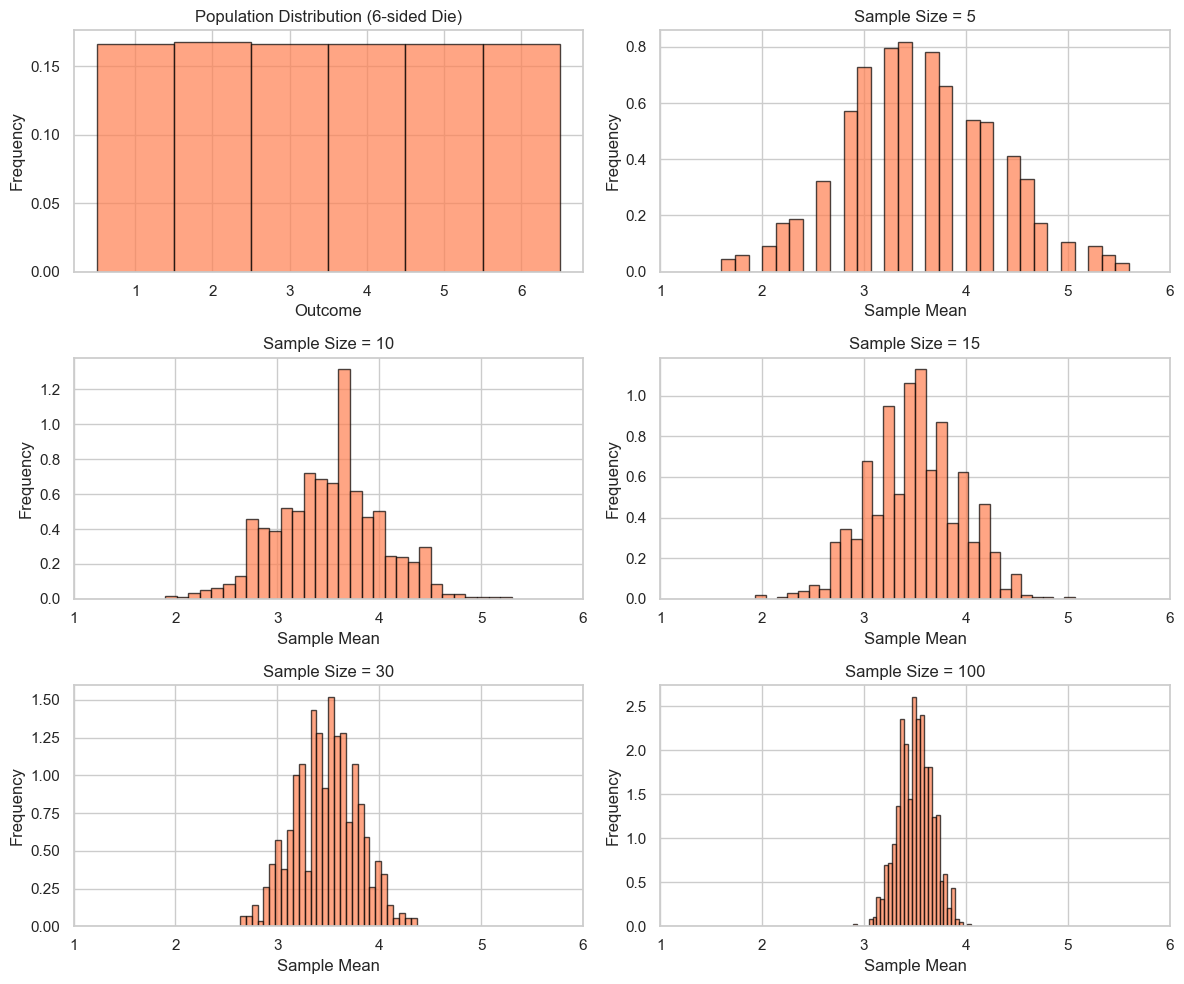

In [9]:
np.random.seed(51)

NORMAL = False

population_size = 1000000
sample_sizes = [5, 10, 15, 30, 100]
num_samples = 1000
die_outcomes = np.arange(1, 7)

population = np.random.randint(1, 7, population_size)

plt.figure(figsize=(12, 10))

plt.subplot(3, 2, 1)
plt.hist(population, bins=np.arange(1, 8) - 0.5, edgecolor='black', color='coral', alpha=0.7, density=True)
plt.title('Population Distribution (6-sided Die)')
plt.xlabel('Outcome')
plt.ylabel('Frequency')

if NORMAL:
    mu, std = norm.fit(population)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2)
    ks_stat, ks_p_value = kstest(population, 'norm', args=(mu, std))
    plt.text(.2, max(p) * 0.8, f'KS stat: {ks_stat:.4f}\np-value: {ks_p_value:.4f}', fontsize=12, color='black')

for i, sample_size in enumerate(sample_sizes):
    sample_means = []
    
    for _ in range(num_samples):
        sample = np.random.choice(die_outcomes, size=sample_size, replace=True)
        sample_means.append(np.mean(sample))
    
    plt.subplot(3, 2, i+2)
    plt.hist(sample_means, bins=30, edgecolor='black', alpha=0.7, color='coral', density=True)
    if NORMAL:
        mu, std = norm.fit(sample_means)
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, std)
        plt.plot(x, p, 'k', linewidth=2)
        
        ks_stat, ks_p_value = kstest(sample_means, 'norm', args=(mu, std))
        plt.text(1.1, max(p) * 0.9, 
             f'KS stat: {ks_stat:.4f}\np-value: {ks_p_value:.4f}', 
             fontsize=12, color='black')
    plt.xlim(1, 6)
    plt.title(f'Sample Size = {sample_size}')
    plt.xlabel('Sample Mean')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Normality Test

In [10]:
from scipy.stats import shapiro, kstest 

### Shapiro-Wilk test

In [11]:
np.random.seed(51)

num_samples = 1000
sample_size = 100

die_outcomes = np.arange(1, 7)
sample_means = []

for _ in range(num_samples):
    sample = np.random.choice(die_outcomes, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

# Perform Shapiro-Wilk test
shapiro_stat, shapiro_p = shapiro(sample_means)
# set the significance level
alpha = 0.05

if shapiro_p > alpha:
    print("Shapiro-Wilk Test: The distribution appears to follow a normal distribution (fail to reject H0).")
else:
    print("Shapiro-Wilk Test: The distribution does NOT follow a normal distribution (reject H0).")

Shapiro-Wilk Test: The distribution appears to follow a normal distribution (fail to reject H0).


### Kolmogorov-Smirnov Test

In [12]:
np.random.seed(51)

sample_size = 100
num_samples = 1000 

die_outcomes = np.arange(1, 7)
sample_means = []

for _ in range(num_samples):
    sample = np.random.choice(die_outcomes, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

ks_stat, ks_p  = kstest(sample_means, 'norm', args=(np.mean(sample_means), np.std(sample_means)))

if ks_p > alpha:
    print("Kolmogorov-Smirnov Test: The distribution appears to follow a normal distribution (fail to reject H0).")
else:
    print("Kolmogorov-Smirnov Test: The distribution does NOT follow a normal distribution (reject H0).")

Kolmogorov-Smirnov Test: The distribution appears to follow a normal distribution (fail to reject H0).


# Plot also fit to normal distribution

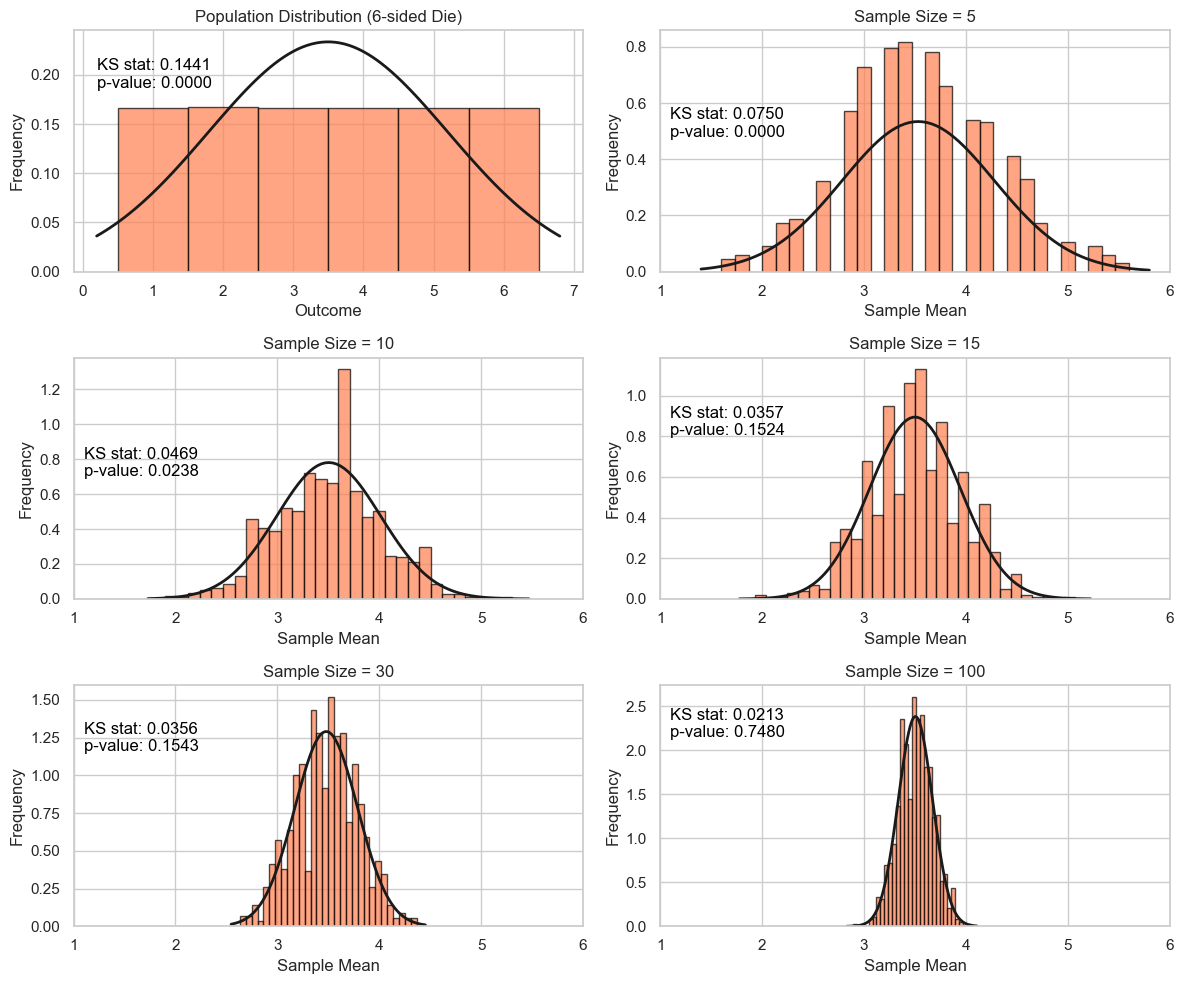

In [13]:
np.random.seed(51)

NORMAL = True

population_size = 1000000
sample_sizes = [5, 10, 15, 30, 100]
num_samples = 1000
die_outcomes = np.arange(1, 7)

population = np.random.randint(1, 7, population_size)

plt.figure(figsize=(12, 10))

# Plot the population distribution
plt.subplot(3, 2, 1)
plt.hist(population, bins=np.arange(1, 8) - 0.5, edgecolor='black', color='coral', alpha=0.7, density=True)
plt.title('Population Distribution (6-sided Die)')
plt.xlabel('Outcome')
plt.ylabel('Frequency')

if NORMAL:
    mu, std = norm.fit(population)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2)
    ks_stat, ks_p_value = kstest(population, 'norm', args=(mu, std))
    plt.text(.2, max(p) * 0.8, f'KS stat: {ks_stat:.4f}\np-value: {ks_p_value:.4f}', fontsize=12, color='black')

for i, sample_size in enumerate(sample_sizes):
    sample_means = []
    
    for _ in range(num_samples):
        sample = np.random.choice(die_outcomes, size=sample_size, replace=True)
        sample_means.append(np.mean(sample))
    
    plt.subplot(3, 2, i+2)
    plt.hist(sample_means, bins=30, edgecolor='black', alpha=0.7, color='coral', density=True)
    if NORMAL:
        mu, std = norm.fit(sample_means)
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, std)
        plt.plot(x, p, 'k', linewidth=2)
        
        ks_stat, ks_p_value = kstest(sample_means, 'norm', args=(mu, std))
        plt.text(1.1, max(p) * 0.9, 
             f'KS stat: {ks_stat:.4f}\np-value: {ks_p_value:.4f}', 
             fontsize=12, color='black')
    plt.xlim(1, 6)
    plt.title(f'Sample Size = {sample_size}')
    plt.xlabel('Sample Mean')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Spourious correlations

In [14]:
from scipy.stats import pearsonr

### https://www.tylervigen.com/spurious/correlation/5920_per-capita-consumption-of-margarine_correlates-with_the-divorce-rate-in-maine

### Data

In [15]:
years = np.array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009])

array_1 = np.array([8.2,7,6.5,5.3,5.2,4,4.6,4.5,4.2,3.7,])
array_2 = np.array([5,4.7,4.6,4.4,4.3,4.1,4.2,4.2,4.2,4.1,])
array_1_name = "Per capita consumption of margarine"
array_2_name = "The divorce rate in Maine"

### Pearson Correlation Coefficient

In [16]:
def calculate_correlation(array1, array2):
    correlation, p_value = pearsonr(array1, array2)
    return correlation, p_value

print(f"Calculating the correlation between {array_1_name} and {array_2_name}...")
correlation, p_value = calculate_correlation(array_1, array_2)

print("Correlation Coefficient:", correlation)
print("P-value:", p_value)

Calculating the correlation between Per capita consumption of margarine and The divorce rate in Maine...
Correlation Coefficient: 0.9925584582238185
P-value: 1.3296773472105363e-08


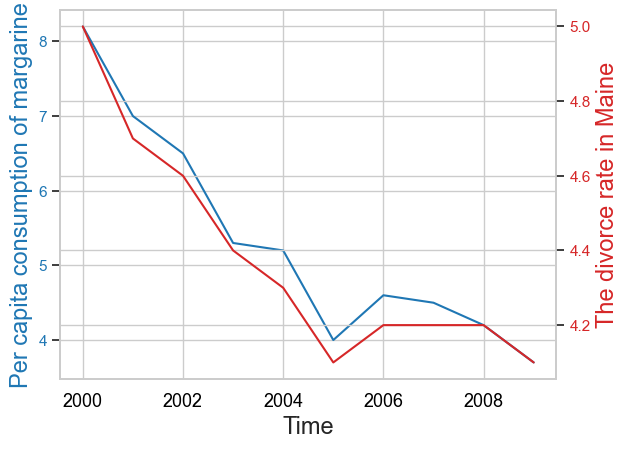

In [17]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Time', fontsize=17)

ax1.set_ylabel(array_1_name, color=color, fontsize=17)
# ax1.set_ylabel('Sample 1', color=color, fontsize=17)

ax1.plot(years, array_1, color=color)
ax1.tick_params(axis='y', labelcolor=color, labelsize=11)

ax2 = ax1.twinx()
color = 'tab:red'

# ax2.set_ylabel('Sample 2', color=color, fontsize=17)
ax2.set_ylabel(array_2_name, color=color, fontsize=17)

ax2.plot(years, array_2, color=color)
ax2.tick_params(axis='y', labelcolor=color, labelsize=11)

ax1.tick_params(axis='x', labelcolor='black', labelsize=13)


# Show the plot
plt.show()

In [18]:
shapiro_stat, shapiro_p = shapiro(array_1)
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}, P-value: {shapiro_p:.4e}")

alpha = 0.05 
if shapiro_p > alpha:
    print("Shapiro-Wilk Test: The distribution appears to follow a normal distribution (fail to reject H0).")
else:
    print("Shapiro-Wilk Test: The distribution does NOT follow a normal distribution (reject H0).")


Shapiro-Wilk Test Statistic: 0.9053, P-value: 2.5033e-01
Shapiro-Wilk Test: The distribution appears to follow a normal distribution (fail to reject H0).


In [19]:
shapiro_stat, shapiro_p = shapiro(array_2)
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}, P-value: {shapiro_p:.4e}")

alpha = 0.05 
if shapiro_p > alpha:
    print("Shapiro-Wilk Test: The distribution appears to follow a normal distribution (fail to reject H0).")
else:
    print("Shapiro-Wilk Test: The distribution does NOT follow a normal distribution (reject H0).")

Shapiro-Wilk Test Statistic: 0.8614, P-value: 7.9162e-02
Shapiro-Wilk Test: The distribution appears to follow a normal distribution (fail to reject H0).


# arbuthnot test

In [20]:
import pandas as pd

In [21]:
df = pd.read_csv('arbuthnot.csv')
df.head()

,year,boys,girls
0,1629,5218,4683
1,1630,4858,4457
2,1631,4422,4102
3,1632,4994,4590
4,1633,5158,4839


In [22]:
df.set_index('year', inplace=True)
df = df.rename(columns={'boys':'Boys', 'girls': 'Girls'})

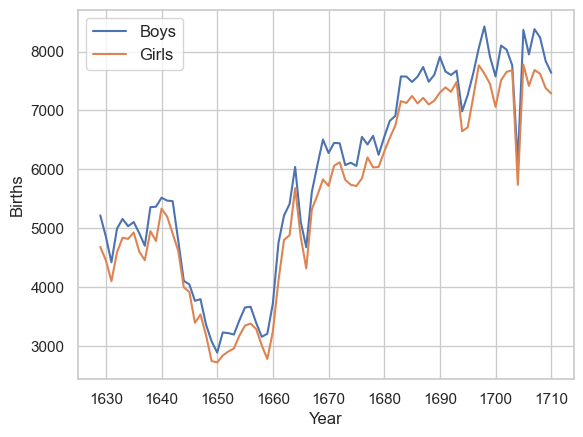

In [23]:
ax = df.plot()
ax.set_xlabel('Year')
ax.set_ylabel('Births')
ax.legend(fontsize=12)